In [1]:
# ! pip install -e ../../savo

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import time
import sys
sys.path.append('../')
from machineIO.objFunc import SingleTaskObjectiveFunction
from machineIO import Evaluator, OracleEvaluator
from IPython.display import display

Failed to import 'phantasy'


In [3]:
n_input = 4
n_output = 2


control_CSETs = [f'X{i}:I_CSET' for i in range(1,n_input+1)]
control_RDs   = [f'X{i}:I_RD' for i in range(1,n_input+1)]
control_min   = -np.ones(n_input)
control_max   =  np.ones(n_input)
control_tols  = 1e-3*(control_max-control_min)
control_init = np.random.randn(n_input)*(control_max - control_min) + control_min
monitor_RDs   = [f'Y{i}' for i in range(1,n_output+1)]
monitor_min   = -2*np.ones(n_output)
monitor_max   =  2*np.ones(n_output)

objective_PVs = monitor_RDs
composite_objective_name = 'rastrigin'

# machineIO

In [4]:
from epics import caget
from machineIO import construct_machineIO

t0 = time.time()
io = construct_machineIO(use_epics=True)
t1 = time.time()
print("--------")
print(f"{int(t1-t0)} sec")

# read using epics
val = [caget("X1:I_CSET"),caget("X1:I_RD")]
t2 = time.time()
print(val)
print(f"{int(t2-t1)} sec")

# read using io
val = [io.caget("X1:I_CSET"),io.caget("X1:I_RD")]
t3 = time.time()
print(val)
print(f"{int(t3-t2)} sec")


# put using io
io.caput("X1:I_CSET",1)
t4 = time.time()
print(f"{int(t4-t3)} sec")


# check result 
time.sleep(0.1) # wait for nework to update CSET PV value
val = [io.caget("X1:I_CSET"),io.caget("X1:I_RD")]
t5 = time.time()
print(val)
print(f"{int(t5-t4)} sec")


# wait and check
time.sleep(5)
t5 = time.time()
val = [io.caget("X1:I_CSET"),io.caget("X1:I_RD")]
t6 = time.time()
print(val)
print(f"{int(t6-t5)} sec")


--------
0 sec
[0.0, -0.05820510573298801]
0 sec
[0.0, -0.05820510573298801]
0 sec
0 sec
[1.0, 0.824846838581935]
0 sec
[1.0, 0.9426026702765903]
0 sec


In [5]:
# Ramp and verify (returns ret string + ramping df)

df = io.fetch_data(["X1:I_CSET", "X1:I_RD"], time_span=2.0, sample_interval=0.2)
display(df)

ret, ramp_df = io.ensure_set(
    setpoint_pv=["X1:I_CSET", "X2:I_CSET"],
    readback_pv=["X1:I_RD", "X2:I_RD"],
    goal=[2.0, 2.0],
    tol=[0.1, 0.1],
    timeout=20,
    sample_interval=0.2,
    extra_monitors=["Y1"],
)
print(ret)
display(ramp_df)


,X1:I_CSET,X1:I_RD
2026-01-16 10:01:29.563271,1.0,0.942745
2026-01-16 10:01:29.790672,1.0,0.942953
2026-01-16 10:01:30.018346,1.0,0.943315
2026-01-16 10:01:30.239576,1.0,0.943761
2026-01-16 10:01:30.457474,1.0,0.943358
2026-01-16 10:01:30.676084,1.0,0.943619
2026-01-16 10:01:30.896285,1.0,0.943404
2026-01-16 10:01:31.125420,1.0,0.943326
2026-01-16 10:01:31.356866,1.0,0.943101
2026-01-16 10:01:31.575788,1.0,0.943075


PutFinish


,X1:I_CSET,X2:I_CSET,X1:I_RD,X2:I_RD,Y1
2026-01-16 10:01:31.746245,2.0,2.0,1.942110,1.345518,-1.904970
2026-01-16 10:01:32.034069,2.0,2.0,1.941753,1.960049,-1.409458


In [6]:
ev = Evaluator(
    machineIO=io,
    control_CSETs=control_CSETs,
    control_RDs=control_RDs,
    control_tols=control_tols,
    monitor_RDs=monitor_RDs,
)
future = ev.submit([1]*n_input)
df, ramp_df = ev.get_result(future)

In [7]:
ramp_df

,X1:I_CSET,X2:I_CSET,X3:I_CSET,X4:I_CSET,X1:I_RD,X2:I_RD,X3:I_RD,X4:I_RD,Y1,Y2
2026-01-16 10:01:32.518853,1.0,1.0,1.0,1.0,0.943398,0.961928,1.079355,1.102545,-1.353299,-0.803878
2026-01-16 10:01:32.800593,1.0,1.0,1.0,1.0,0.943261,0.961781,1.079495,1.102585,-1.346202,-0.481339
2026-01-16 10:01:33.049277,1.0,1.0,1.0,1.0,0.943501,0.961344,1.079689,1.102878,-1.358574,-0.494807
2026-01-16 10:01:33.297573,1.0,1.0,1.0,1.0,0.943922,0.961428,1.079687,1.103004,-1.365202,-0.462844
2026-01-16 10:01:33.548695,1.0,1.0,1.0,1.0,0.943783,0.961240,1.079057,1.102510,-1.358112,-0.473884
...,...,...,...,...,...,...,...,...,...,...
2026-01-16 10:01:51.481836,1.0,1.0,1.0,1.0,0.946103,0.959103,1.077778,1.103007,-1.360451,-0.496846
2026-01-16 10:01:51.732690,1.0,1.0,1.0,1.0,0.946217,0.959183,1.077774,1.103214,-1.384277,-0.474516
2026-01-16 10:01:51.982008,1.0,1.0,1.0,1.0,0.946427,0.959005,1.077544,1.103084,-1.376596,-0.482925
2026-01-16 10:01:52.239730,1.0,1.0,1.0,1.0,0.946424,0.959215,1.077508,1.103322,-1.375992,-0.495790


In [8]:
df

,X1:I_CSET,X2:I_CSET,X3:I_CSET,X4:I_CSET,X1:I_RD,X2:I_RD,X3:I_RD,X4:I_RD,Y1,Y2
2026-01-16 10:01:52.877226,1.0,1.0,1.0,1.0,0.947199,0.959691,1.076805,1.103774,-1.372149,-0.464289
2026-01-16 10:01:53.096142,1.0,1.0,1.0,1.0,0.947322,0.959668,1.077214,1.103493,-1.361754,-0.470333
2026-01-16 10:01:53.327275,1.0,1.0,1.0,1.0,0.946784,0.959478,1.077520,1.103374,-1.375016,-0.494314
2026-01-16 10:01:53.548035,1.0,1.0,1.0,1.0,0.946827,0.959455,1.077442,1.103424,-1.381492,-0.486932
2026-01-16 10:01:53.766204,1.0,1.0,1.0,1.0,0.947098,0.959455,1.077348,1.104116,-1.359806,-0.483048
2026-01-16 10:01:54.014897,1.0,1.0,1.0,1.0,0.947199,0.959281,1.077288,1.103783,-1.374509,-0.478467
2026-01-16 10:01:54.246317,1.0,1.0,1.0,1.0,0.947014,0.959158,1.077341,1.104009,-1.378969,-0.487817
2026-01-16 10:01:54.479248,1.0,1.0,1.0,1.0,0.946712,0.959111,1.077237,1.104174,-1.385434,-0.467978
2026-01-16 10:01:54.701084,1.0,1.0,1.0,1.0,0.946871,0.959258,1.076997,1.104333,-1.357431,-0.491985
2026-01-16 10:01:54.933826,1.0,1.0,1.0,1.0,0.946768,0.959230,1.076930,1.103985,-1.370999,-0.484045


# obj_func

: rastirigin over 2D latent space of random NN for both high-dim and visualization

In [9]:
noise = 0.0

def rastrigin(x,noise=noise):
    x = torch.as_tensor(x)
    b,d = x.shape
    y = torch.sum(x**2 - torch.cos(2*np.pi*x),axis=1)/d +1
    return 1-y + torch.randn(b)*noise

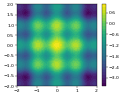

In [10]:
grid = np.linspace(-2,2,128)
x1,x2 = np.meshgrid(grid,grid)
xgrid = np.vstack((x1.flatten(), x2.flatten())).T
ygrid = rastrigin(xgrid,noise=0)
def plot_contour(figsize=(4,3.3),dpi=128):
    fig,ax = plt.subplots(figsize=figsize,dpi=dpi)
    cs = ax.tricontourf(xgrid[:,0],xgrid[:,1],ygrid,levels=32)
    fig.colorbar(cs,ax=ax)
    return fig,ax
fig,ax = plot_contour(dpi=32)

In [11]:
obj_func = SingleTaskObjectiveFunction(
    objective_PVs = monitor_RDs,
    composite_objective_name = composite_objective_name,
    custom_function = rastrigin,
    objective_goal = None, 
    objective_weight = None,
    objective_tolerance = None,
)

In [12]:
evaluator = Evaluator(
    machineIO = io,
    control_CSETs = control_CSETs,
    control_RDs = control_RDs,
    control_tols = control_tols,
    monitor_RDs = monitor_RDs,
    df_manipulators = [obj_func.calculate_objectives_from_df],
)

In [13]:
oracle_key_names = {f'x{i+1}':f'X{i+1}:I_RD' for i in range(len(control_CSETs))}
oracle_key_names['y'] = 'rastrigin'

oracle = OracleEvaluator(
    machineIO = io,
    control_CSETs = control_CSETs,
    control_RDs = control_RDs,
    control_tols = control_tols,
    monitor_RDs = monitor_RDs,
    oracle_key_names = oracle_key_names,
    df_manipulators = [obj_func.calculate_objectives_from_df],

)

In [14]:
oracle_dic = oracle()
oracle_dic

{'x1': array([0.9466899]),
 'x2': array([0.95949403]),
 'x3': array([1.07615308]),
 'x4': array([1.10448686]),
 'y': array([-1.90184613])}

In [15]:
oracle_dic = oracle(np.zeros(len(control_CSETs)))
oracle_dic

{'x1': array([-0.05113032]),
 'x2': array([-0.04054771]),
 'x3': array([0.07677307]),
 'x4': array([0.10296423]),
 'y': array([-3.02847568]),
 'ramping_x1': array([-0.05169609]),
 'ramping_x2': array([-0.04088349]),
 'ramping_x3': array([0.08194639]),
 'ramping_x4': array([0.11082676]),
 'ramping_y': array([-3.04256986])}